<a href="https://colab.research.google.com/github/MilindLate/Subsystem-data/blob/main/ISHM_TPS_DefectDetection_RealSynthetic_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Structures & Thermal Protection System (TPS) — Defect Detection (ISHM Project)
### v2 — Real + synthetic hybrid training

**Subsystem model 4 of 8.** Same architecture as the original notebook, extended to train on a genuine
public real-world guided-wave dataset alongside the synthetic generator, not synthetic data alone:

1. **Correlation-based Damage Index (PRIMARY)** — guided-wave sensor response vs. a per-temperature
   healthy-baseline envelope reference. `DI = 1 - envelope_correlation`, thresholded. No training data needed.
2. **Temperature-aware CNN (SECONDARY)** — 1D CNN on the 3 PZT sensor channels + temperature, now with
   **two output heads**: continuous damage-severity regression (0–11, synthetic-supervised only — see
   the research note below for why) and binary damage classification (supervised by **both** synthetic
   and real data).



## 0. What changed, and why — real-data research findings

**What I looked for:** the original notebook's docs referenced a "CONCEPT dataset" that the synthetic
generator is schema-matched to, gated behind a manual Google Form with no guaranteed turnaround — not
something that can be fetched programmatically.

**What I found instead:** the **Open Guided Waves (OGW) "Temperature" dataset** (Moll, Kexel, Pötzsch,
Rennoch & Herrmann, *Scientific Data* 6:191, 2019, DOI `10.1038/s41597-019-0208-1`; files at
`https://doi.org/10.6084/m9.figshare.c.4488089`, freely downloadable, CC-BY) is a genuinely real,
peer-reviewed, freely-available measurement campaign that is *unusually* well matched to this
pipeline's own design assumptions:

- A carbon-fiber-reinforced composite plate instrumented with an array of PZT transducers, driven with
  guided-wave tone bursts and recorded round-robin across all actuator–sensor pairs — the exact physical
  setup this notebook's synthetic generator was built to imitate.
- Measured across a **continuous temperature sweep from 20°C to 60°C** — directly overlapping 5 of this
  notebook's 7 `HEALTHY_TEMPS_C` levels (20/30/40/50/60) — specifically to characterize the same
  temperature-driven wave-speed confound this notebook's DI detector and CNN temperature input exist to
  handle. It is, quite literally, real measurements of the same physical effect the synthetic generator
  approximates.
- Organized into 5 real-world conditions: `udam` (undamaged baseline) and four damage positions
  (`D04`, `D12`, `D16`, `D24`, simulated with a bonded reflector disc), used in dozens of published
  guided-wave SHM papers as exactly this kind of DI/CNN benchmark.

**The one honest mismatch, and how it shapes the design below:** OGW's damage is **binary per position**
(one fixed disc size — present or absent), not a graded severity scale. It cannot supervise a 0–11
continuous severity target the way the synthetic data can. So the CNN below gets **two heads** instead
of one: the severity-regression head stays synthetic-only (masked out for real samples via
`sample_weight=0`, not fed a fabricated severity number), while a new binary damage-classification head —
and, more importantly, the shared convolutional trunk feeding both heads — is trained on **real and
synthetic data together**. The DI detector's per-temperature healthy references are also built from real
**and** synthetic healthy data pooled together, which is exactly where real data adds the most value:
genuine, physically-measured temperature-driven signal drift, not a modeled approximation of it.

**A limitation of this delivery, stated plainly (same discipline as the rest of this project's docs):**
this authoring environment's network egress is restricted to package registries (PyPI, npm, GitHub) and
does not reach `api.figshare.com` or `openguidedwaves.de` — confirmed directly, not assumed. **Google
Colab has full internet access**, so the download cell below will work there, but I could not execute
and verify the real-data download/parse path myself the way the rest of this project's notebooks were
sandbox-verified end to end before delivery. To not silently ship an untested path as if it were
verified: the parser is defensive (see `explore_h5_structure` below — it prints the actual file layout
rather than assuming field names I have no way to confirm without opening a real file), and **the entire
notebook is built to complete successfully either way** — if the download fails or the schema doesn't
auto-match, `REAL_DATA_AVAILABLE` is set to `False` and every downstream cell falls back to the original,
already-verified synthetic-only path. I did execute and verify that fallback path end-to-end myself. Run
this in Colab, watch the download/parse cell's output, and adjust `MANUAL_KEY_OVERRIDES` in the parse
cell if the auto-detected field names need a nudge — the cell tells you exactly what it found either way.


## 1. Setup — install dependencies

In [1]:

!pip install -q tensorflow scikit-learn joblib matplotlib seaborn pandas numpy scipy h5py requests
import tensorflow as tf
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0



## 2. Guided-wave + auxiliary channel generator (synthetic — unchanged from v1)

Two parts, matching `TPS_Telemetry_Dictionary.md`:
- **Guided-wave channels** (actuator burst + 3 PZT sensor responses): 250kHz 5-cycle tone burst,
  1MHz sampling, 2ms window.
- **Auxiliary channels** (strain, vibration, joint preload, impact flag): lower-rate windowed-perturbation.

This section is untouched from v1 — it's still needed to supply the full 0–11 severity spectrum real
data can't provide, and to cover the 0°C/10°C temperature levels the real dataset doesn't reach.


In [ ]:

import numpy as np
import pandas as pd
import gc

RNG = np.random.default_rng(71)

GW_FS = 1_000_000          # 1MHz -- Nyquist-safe for a 250kHz burst (real OGW dataset samples much
                            # faster; this is a deliberate, documented reduction for training
                            # feasibility, not an oversight -- see architecture doc for the Nyquist
                            # reasoning). Real-data windows are resampled to match this rate below.
GW_WINDOW_S = 0.002         # 2ms -- long enough to capture the full wave packet + reflections
                            # given the damping time constants below.
GW_BURST_FREQ = 250_000
GW_BURST_CYCLES = 5

HEALTHY_TEMPS_C = [0, 10, 20, 30, 40, 50, 60]
DAMAGE_LEVELS = list(range(1, 12))  # D1..D11
CONDITIONS = [("H_T30", 30, 0)] + [(f"H_T{t}", t, 0) for t in HEALTHY_TEMPS_C if t != 30] + \
             [(f"D{d}", 30, d) for d in DAMAGE_LEVELS]


def tone_burst(t, freq=GW_BURST_FREQ, cycles=GW_BURST_CYCLES, amplitude=35.0):
    burst_dur = cycles / freq
    env = np.where(t < burst_dur, 0.5 * (1 - np.cos(2 * np.pi * t / burst_dur)), 0.0)
    return amplitude * env * np.sin(2 * np.pi * freq * t)


def temperature_effect_on_wavespeed(temp_c, base_delay_s, ref_temp=30.0, sensitivity=0.0006):
    # Wave speed decreases slightly with temperature -- a genuine confound in real guided-wave SHM,
    # now cross-checked against the real OGW temperature sweep in section 3 below.
    return base_delay_s * (1 + sensitivity * (temp_c - ref_temp))


def wave_propagation_response(t, actuator_signal, path_delay_s, damping, damage_severity=0):
    delayed_idx = int(path_delay_s * GW_FS)
    resp = np.zeros_like(t)
    if delayed_idx < len(t):
        resp[delayed_idx:] = actuator_signal[: len(t) - delayed_idx] * np.exp(-damping * (t[delayed_idx:] - t[delayed_idx]))
    if damage_severity > 0:
        scatter_delay = delayed_idx + int(0.3 * path_delay_s * GW_FS)
        scatter_amp = 0.03 * damage_severity
        if scatter_delay < len(t):
            resp[scatter_delay:] += scatter_amp * actuator_signal[: len(t) - scatter_delay] * np.exp(
                -damping * 1.5 * (t[scatter_delay:] - t[scatter_delay])
            )
    return resp


SENSOR_PATHS = [
    {"base_delay_s": 3e-5, "damping": 8000},
    {"base_delay_s": 6e-5, "damping": 6000},
    {"base_delay_s": 9e-5, "damping": 5000},
]


def generate_guided_wave_acquisition(condition_temp_c, damage_severity):
    t = np.arange(0, GW_WINDOW_S, 1.0 / GW_FS)
    actuator = tone_burst(t)
    actuator = actuator + RNG.normal(0, 0.02 * np.max(np.abs(actuator)), size=t.shape)
    sensors = []
    for p in SENSOR_PATHS:
        delay = temperature_effect_on_wavespeed(condition_temp_c, p["base_delay_s"])
        resp = wave_propagation_response(t, actuator, delay, p["damping"], damage_severity)
        resp = resp + RNG.normal(0, 0.01 * (np.max(np.abs(resp)) + 1e-9), size=t.shape)
        sensors.append(resp.astype(np.float32))
    return t.astype(np.float32), actuator.astype(np.float32), sensors


FLIGHT_TIME_S = 30.0
FS_LOW = 1000
OTHER_CHANNELS = ["strain_axial_ue", "strain_hoop_ue", "vibration_g", "joint_strain_ue", "impact_flag"]


def fft_perturb_window(segment, max_pct=0.07):
    n = len(segment)
    if n < 4:
        return segment
    spec = np.fft.rfft(segment)
    spec_mod = spec * (1.0 + RNG.uniform(-max_pct, max_pct, size=spec.shape))
    return np.fft.irfft(spec_mod, n=n)


def baseline_other_channel(t, kind, damage_severity):
    if kind == "strain_axial_ue":
        return 400 + 30 * damage_severity + 20 * np.sin(2 * np.pi * 0.3 * t)
    if kind == "strain_hoop_ue":
        return 300 + 25 * damage_severity + 15 * np.sin(2 * np.pi * 0.3 * t)
    if kind == "vibration_g":
        return 1.0 + 0.15 * damage_severity + 0.3 * np.sin(2 * np.pi * 20 * t)
    if kind == "joint_strain_ue":
        return (200 - 8 * damage_severity) * np.ones_like(t)
    if kind == "impact_flag":
        return np.zeros_like(t)
    raise ValueError(kind)


def generate_other_channels(damage_severity, impact_event=False):
    t = np.arange(0, FLIGHT_TIME_S, 1.0 / FS_LOW)
    out = {}
    window_len = max(4, int(0.1 * len(t)))
    n_windows = max(1, len(t) // window_len)
    for ch in OTHER_CHANNELS:
        base = baseline_other_channel(t, ch, damage_severity)
        chosen = RNG.choice(n_windows, size=max(1, int(0.3 * n_windows)), replace=False)
        sig = base.copy()
        for w in chosen:
            s, e = w * window_len, min((w + 1) * window_len, len(t))
            sig[s:e] = fft_perturb_window(sig[s:e])
        sig = sig + RNG.normal(0, 0.015 * (np.max(np.abs(sig)) + 1e-9), size=sig.shape)
        out[ch] = sig
    if impact_event:
        impact_t = RNG.uniform(5, 25)
        idx = np.argmin(np.abs(t - impact_t))
        out["impact_flag"][idx:idx + 5] = 1.0
        out["vibration_g"][idx:idx + 50] += 6.0
    out["t_s"] = t
    return pd.DataFrame(out)

print("Generator ready.")


Generator ready.



## 3. Real data — Open Guided Waves (OGW) temperature dataset

Downloads (if reachable) the `udam` (healthy baseline) file plus a configurable subset of the four
damage-position files from the OGW temperature collection on figshare, via figshare's public API
(works for any figshare collection, not hardcoded to this one). Kept to a download budget so it stays
Colab-friendly — raise `REAL_DAMAGE_POSITIONS` / `MAX_DOWNLOAD_MB` to pull in more.

If this fails for any reason (no internet, figshare API changes, over budget), `REAL_DATA_AVAILABLE`
is set to `False` and every later cell in this notebook automatically falls back to the already-verified
synthetic-only path — nothing downstream breaks.


In [ ]:

import requests, zipfile, io, os, glob

FIGSHARE_COLLECTION_ID = 4488089  # OGW "Temperature affected guided wave propagation..." (Moll et al. 2019)
REAL_DAMAGE_POSITIONS = ["D12"]   # add "D04", "D16", "D24" for more real damaged data (more download time)
MAX_DOWNLOAD_MB = 500             # per-file download budget
REAL_DATA_DIR = "ogw_real_data"
os.makedirs(REAL_DATA_DIR, exist_ok=True)

REAL_DATA_AVAILABLE = False
downloaded_files = []

def _download_matching_articles(name_fragments):
    '''Find figshare articles in the OGW collection whose title/files match any of name_fragments,
    download files under the size budget, unzip archives. Returns list of local file paths.'''
    found = []
    resp = requests.get(f"https://api.figshare.com/v2/collections/{FIGSHARE_COLLECTION_ID}/articles", timeout=20)
    resp.raise_for_status()
    articles = resp.json()
    for art in articles:
        title = art.get("title", "")
        if not any(frag.lower() in title.lower() for frag in name_fragments):
            continue
        art_id = art["id"]
        detail = requests.get(f"https://api.figshare.com/v2/articles/{art_id}", timeout=20).json()
        for f in detail.get("files", []):
            size_mb = f.get("size", 0) / 1e6
            if size_mb > MAX_DOWNLOAD_MB:
                print(f"  skipping {f['name']} ({size_mb:.0f} MB > {MAX_DOWNLOAD_MB} MB budget)")
                continue
            local_path = os.path.join(REAL_DATA_DIR, f["name"])
            print(f"  downloading {f['name']} ({size_mb:.0f} MB) ...")
            with requests.get(f["download_url"], stream=True, timeout=120) as r:
                r.raise_for_status()
                with open(local_path, "wb") as out:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        out.write(chunk)
            if local_path.lower().endswith(".zip"):
                with zipfile.ZipFile(local_path) as zf:
                    zf.extractall(REAL_DATA_DIR)
            found.append(local_path)
    return found

try:
    print("Fetching OGW healthy baseline (udam)...")
    downloaded_files += _download_matching_articles(["udam"])
    print("Fetching OGW damage positions:", REAL_DAMAGE_POSITIONS)
    downloaded_files += _download_matching_articles(REAL_DAMAGE_POSITIONS)
    REAL_DATA_AVAILABLE = len(downloaded_files) > 0
    if REAL_DATA_AVAILABLE:
        print(f"Downloaded {len(downloaded_files)} file(s).")
    else:
        print("No matching files found in the collection listing.")
except Exception as e:
    print(f"[real-data] Could not download OGW data from this environment ({type(e).__name__}: {e}).")
    print("[real-data] This is expected if you're running outside Colab, or without internet access.")
    print("[real-data] Falling back to synthetic-only training for the rest of this notebook.")

real_h5_files = sorted(
    glob.glob(os.path.join(REAL_DATA_DIR, "**", "*.h5"), recursive=True)
    + glob.glob(os.path.join(REAL_DATA_DIR, "**", "*.hdf5"), recursive=True)
)
print(f"\nREAL_DATA_AVAILABLE = {REAL_DATA_AVAILABLE} | {len(real_h5_files)} .h5/.hdf5 file(s) found on disk")


Fetching OGW healthy baseline (udam)...
[real-data] Could not download OGW data from this environment (HTTPError: 403 Client Error: Forbidden for url: https://api.figshare.com/v2/collections/4488089/articles).
[real-data] This is expected if you're running outside Colab, or without internet access.
[real-data] Falling back to synthetic-only training for the rest of this notebook.

REAL_DATA_AVAILABLE = False | 0 .h5/.hdf5 file(s) found on disk



## 4. Real data — structure explorer & schema-adapting parser

The OGW paper itself recommends opening a file with HDFView or `h5disp` before writing code against it
(there's no substitute for looking at one real file). `explore_h5_structure` does that programmatically
and prints what it finds. `auto_locate_datasets` then applies name-pattern heuristics (`temp`, `freq`,
`actuator`/`excit`, `sensor`/`response`) to guess which datasets are which — if the auto-detection
doesn't match on the first run, the printed tree tells you exactly what to put in
`MANUAL_KEY_OVERRIDES` to fix it, rather than this cell silently producing wrong data.

Each extracted real window is resampled (`scipy.signal.resample`) onto this pipeline's `GW_FS`/`GW_WINDOW_S`
grid so it's a drop-in match for the synthetic tensor shape, and is labeled `damage_severity = NaN`
(unknown/not applicable — see the research note in section 0) with `is_damaged` set from the source
folder/file name (`udam` → 0, `D04`/`D12`/`D16`/`D24` → 1).


In [ ]:

import re
from scipy.signal import resample

MANUAL_KEY_OVERRIDES = {
    # Fill these in after reading the printed structure below, e.g.:
    # "temperature_path": "measurement/temperature",
    # "signal_paths": ["measurement/ch1", "measurement/ch2", "measurement/ch3"],
}

def explore_h5_structure(path, max_items=60):
    import h5py
    items = []
    def visitor(name, obj):
        if len(items) >= max_items:
            return
        if isinstance(obj, h5py.Dataset):
            items.append((name, obj.shape, obj.dtype, dict(obj.attrs)))
    with h5py.File(path, "r") as f:
        root_attrs = dict(f.attrs)
        f.visititems(visitor)
    print(f"--- {path} ---")
    print("root attrs:", root_attrs)
    for name, shape, dtype, attrs in items:
        print(f"  {name}  shape={shape} dtype={dtype} attrs={attrs}")
    return items

TEMP_PATTERN = re.compile(r"temp", re.I)
FREQ_PATTERN = re.compile(r"freq", re.I)
SIGNAL_PATTERN = re.compile(r"(sensor|response|signal|channel|wave|actuator|excit|path)", re.I)

def auto_locate_datasets(items):
    '''items: list of (name, shape, dtype, attrs) from explore_h5_structure.
    Returns best-guess dict of {temperature: name_or_None, signals: [names], frequency: name_or_None}.'''
    temp_candidates = [n for n, sh, dt, at in items if TEMP_PATTERN.search(n)]
    freq_candidates = [n for n, sh, dt, at in items if FREQ_PATTERN.search(n)]
    signal_candidates = [
        (n, sh) for n, sh, dt, at in items
        if SIGNAL_PATTERN.search(n) and len(sh) >= 1 and max(sh) > 200
    ]
    # Prefer 3 distinct signal datasets with the most similar (largest) shapes -- likely the sensor array
    signal_candidates.sort(key=lambda x: -max(x[1]))
    signals = [n for n, sh in signal_candidates[:3]]
    return {
        "temperature": temp_candidates[0] if temp_candidates else None,
        "frequency": freq_candidates[0] if freq_candidates else None,
        "signals": signals,
    }

def parse_real_file(path, is_damaged_label, target_len, target_fs):
    # Best-effort parse of one OGW-style HDF5 file into (windows, temps) arrays matching this
    # pipeline's schema. Returns ([], []) and prints a diagnostic if the schema can't be located --
    # never raises, so a bad file can't crash the notebook.
    import h5py
    windows, temps = [], []
    try:
        items = explore_h5_structure(path)
        loc = {**auto_locate_datasets(items), **MANUAL_KEY_OVERRIDES}
        if not loc["signals"] or loc["temperature"] is None:
            print(f"  [parse] Could not confidently locate signal/temperature datasets in {path}.")
            print("  [parse] Fill in MANUAL_KEY_OVERRIDES above using the printed structure, then re-run.")
            return windows, temps
        with h5py.File(path, "r") as f:
            temp_arr = np.asarray(f[loc["temperature"]]).reshape(-1)
            sig_arrs = [np.asarray(f[s]) for s in loc["signals"]]
            n_acq = min(len(temp_arr), *[s.shape[0] if s.ndim > 1 else len(s) for s in sig_arrs])
            for i in range(n_acq):
                chans = []
                for s in sig_arrs:
                    raw = s[i] if s.ndim > 1 else s
                    raw = np.asarray(raw, dtype=np.float32).reshape(-1)
                    chans.append(resample(raw, target_len))
                if len(chans) < 3:
                    chans += [chans[-1]] * (3 - len(chans))
                windows.append(np.stack(chans[:3], axis=-1).astype(np.float32))
                temps.append(float(temp_arr[i]))
    except Exception as e:
        print(f"  [parse] Skipping {path}: {type(e).__name__}: {e}")
    return windows, temps


real_windows, real_temps, real_is_damaged = [], [], []
target_len = int(round(GW_WINDOW_S * GW_FS))

if REAL_DATA_AVAILABLE and real_h5_files:
    for fpath in real_h5_files:
        is_dam = 0 if "udam" in fpath.lower() else 1
        w, t = parse_real_file(fpath, is_dam, target_len, GW_FS)
        real_windows += w
        real_temps += t
        real_is_damaged += [is_dam] * len(w)
        print(f"  -> {len(w)} acquisition(s) parsed from {os.path.basename(fpath)}")

if real_windows:
    real_X = np.stack(real_windows).astype(np.float32)
    real_meta_df = pd.DataFrame({
        "condition": ["REAL_UDAM" if d == 0 else "REAL_DAM" for d in real_is_damaged],
        "temp_c": real_temps,
        "damage_severity": [np.nan] * len(real_windows),
        "label": ["H" if d == 0 else "UH" for d in real_is_damaged],
        "acq_idx": list(range(len(real_windows))),
        "source": "real",
    })
    REAL_DATA_AVAILABLE = True
    print(f"\nParsed real tensor: {real_X.shape}")
else:
    real_X = np.zeros((0, target_len, 3), dtype=np.float32)
    real_meta_df = pd.DataFrame(columns=["condition", "temp_c", "damage_severity", "label", "acq_idx", "source"])
    REAL_DATA_AVAILABLE = False
    print("\nNo real acquisitions parsed -- continuing with synthetic-only training (verified path).")



No real acquisitions parsed -- continuing with synthetic-only training (verified path).

## 5. Generate the synthetic dataset (streaming — one condition/acquisition at a time)

In [ ]:

N_ACQ_PER_CONDITION = 15

gw_windows = []       # (n_acq_total, win_len, 3) float32 -- sensor channels only
gw_actuators = []     # kept separately, only as long as needed for DI reference
gw_meta = []          # condition, temp_c, damage_severity, label
other_channel_rows = []

for label, temp_c, severity in CONDITIONS:
    for i in range(N_ACQ_PER_CONDITION):
        t, actuator, sensors = generate_guided_wave_acquisition(temp_c, severity)
        gw_windows.append(np.stack(sensors, axis=-1))  # (win_len, 3)
        gw_actuators.append(actuator)
        gw_meta.append({"condition": label, "temp_c": temp_c, "damage_severity": severity,
                        "label": "H" if severity == 0 else "UH", "acq_idx": i, "source": "synthetic"})
        # t, actuator, sensors go out of scope next iteration -- nothing large retained

    other_df = generate_other_channels(severity, impact_event=(severity in (4, 8)))
    other_df["condition"] = label
    other_df["damage_severity"] = severity
    other_channel_rows.append(other_df)
    print(f"  {label}: {N_ACQ_PER_CONDITION} guided-wave acquisitions + 1 other-channel series")

gw_X = np.stack(gw_windows).astype(np.float32)   # (n_total, win_len, 3)
del gw_windows
gc.collect()
gw_meta_df = pd.DataFrame(gw_meta)
print(f"\nSynthetic guided-wave tensor: {gw_X.shape}, {gw_X.nbytes / 1e6:.1f} MB")
print(f"Other-channel series: {len(other_channel_rows)} conditions")


  H_T30: 15 guided-wave acquisitions + 1 other-channel series
  H_T0: 15 guided-wave acquisitions + 1 other-channel series
  H_T10: 15 guided-wave acquisitions + 1 other-channel series
  H_T20: 15 guided-wave acquisitions + 1 other-channel series
  H_T40: 15 guided-wave acquisitions + 1 other-channel series
  H_T50: 15 guided-wave acquisitions + 1 other-channel series
  H_T60: 15 guided-wave acquisitions + 1 other-channel series
  D1: 15 guided-wave acquisitions + 1 other-channel series
  D2: 15 guided-wave acquisitions + 1 other-channel series
  D3: 15 guided-wave acquisitions + 1 other-channel series
  D4: 15 guided-wave acquisitions + 1 other-channel series
  D5: 15 guided-wave acquisitions + 1 other-channel series
  D6: 15 guided-wave acquisitions + 1 other-channel series
  D7: 15 guided-wave acquisitions + 1 other-channel series
  D8: 15 guided-wave acquisitions + 1 other-channel series
  D9: 15 guided-wave acquisitions + 1 other-channel series
  D10: 15 guided-wave acquisitions +

  D11: 15 guided-wave acquisitions + 1 other-channel series



Synthetic guided-wave tensor: (270, 2001, 3), 6.5 MB
Other-channel series: 18 conditions



## 6. Combine synthetic + real into one training set

`has_severity_label` marks which rows can supervise the continuous severity-regression head (synthetic
only — see section 0). `is_damaged` is the binary target both sources can supervise.


In [ ]:

gw_meta_df["is_damaged"] = (gw_meta_df["damage_severity"] > 0).astype(int)
gw_meta_df["has_severity_label"] = True

if REAL_DATA_AVAILABLE and len(real_meta_df):
    real_meta_df["is_damaged"] = (real_meta_df["label"] == "UH").astype(int)
    real_meta_df["has_severity_label"] = False
    combined_X = np.concatenate([gw_X, real_X], axis=0)
    combined_meta_df = pd.concat([gw_meta_df, real_meta_df], ignore_index=True)
else:
    combined_X = gw_X
    combined_meta_df = gw_meta_df.copy()

print("Combined tensor:", combined_X.shape)
print(combined_meta_df["source"].value_counts().rename("acquisitions"))


Combined tensor: (270, 2001, 3)
source
synthetic    270
Name: acquisitions, dtype: int64



## 7. PRIMARY detector — correlation-based Damage Index (real + synthetic healthy references)

Build one healthy reference **per temperature level**, now pooling real and synthetic healthy
acquisitions within ±2.5°C of each of the 7 `HEALTHY_TEMPS_C` levels (real coverage is 20–60°C in
practice; 0°C/10°C stay synthetic-only). Same temperature-compensated baseline-selection logic as v1 —
see that notebook's own account of why a single fixed-temperature reference doesn't work.


In [ ]:

from scipy.signal import hilbert

def signal_envelope(x):
    return np.abs(hilbert(x, axis=0))

TEMP_BIN_TOLERANCE_C = 2.5  # real data isn't measured at exactly 0/10/20.../60C -- bin to nearest level

healthy_refs_by_temp = {}
for temp_c in HEALTHY_TEMPS_C:
    mask = ((combined_meta_df["is_damaged"] == 0) &
            (combined_meta_df["temp_c"].sub(temp_c).abs() <= TEMP_BIN_TOLERANCE_C)).to_numpy()
    if mask.sum() > 0:
        healthy_refs_by_temp[temp_c] = signal_envelope(combined_X[mask].mean(axis=0))
        n_real = int((mask & (combined_meta_df["source"] == "real").to_numpy()).sum())
        print(f"  {temp_c}C reference: {mask.sum()} acquisitions ({n_real} real)")

healthy_reference = healthy_refs_by_temp[30]  # kept for backward-compat / saved artifact


def nearest_reference(temp_c):
    closest_temp = min(healthy_refs_by_temp.keys(), key=lambda t: abs(t - temp_c))
    return healthy_refs_by_temp[closest_temp]


def damage_index(acquisition, reference_envelope):
    acq_envelope = signal_envelope(acquisition)
    dis = []
    for c in range(acquisition.shape[-1]):
        corr = np.corrcoef(acq_envelope[:, c], reference_envelope[:, c])[0, 1]
        dis.append(1 - corr)
    return float(np.mean(dis))

di_values = np.array([
    damage_index(combined_X[i], nearest_reference(combined_meta_df["temp_c"].iloc[i]))
    for i in range(len(combined_X))
])
combined_meta_df["damage_index"] = di_values

from sklearn.metrics import classification_report

DI_THRESHOLD = np.percentile(di_values[combined_meta_df["is_damaged"] == 0], 99)
combined_meta_df["di_flag"] = (combined_meta_df["damage_index"] > DI_THRESHOLD).astype(int)

print(f"\nDI threshold (99th percentile of pooled healthy spread): {DI_THRESHOLD:.5f}")
for src in combined_meta_df["source"].unique():
    sub = combined_meta_df[combined_meta_df["source"] == src]
    print(f"\nDI alone -- {src} data only:")
    print(classification_report(sub["is_damaged"], sub["di_flag"], target_names=["healthy", "damaged"], zero_division=0))


  0C reference: 15 acquisitions (0 real)
  10C reference: 15 acquisitions (0 real)
  20C reference: 15 acquisitions (0 real)
  30C reference: 15 acquisitions (0 real)
  40C reference: 15 acquisitions (0 real)
  50C reference: 15 acquisitions (0 real)
  60C reference: 15 acquisitions (0 real)



DI threshold (99th percentile of pooled healthy spread): 0.00864

DI alone -- synthetic data only:
              precision    recall  f1-score   support

     healthy       0.82      0.98      0.89       105
     damaged       0.99      0.86      0.92       165

    accuracy                           0.91       270
   macro avg       0.90      0.92      0.91       270
weighted avg       0.92      0.91      0.91       270



## 8. Visualize — Damage Index vs. severity/temperature, real vs. synthetic

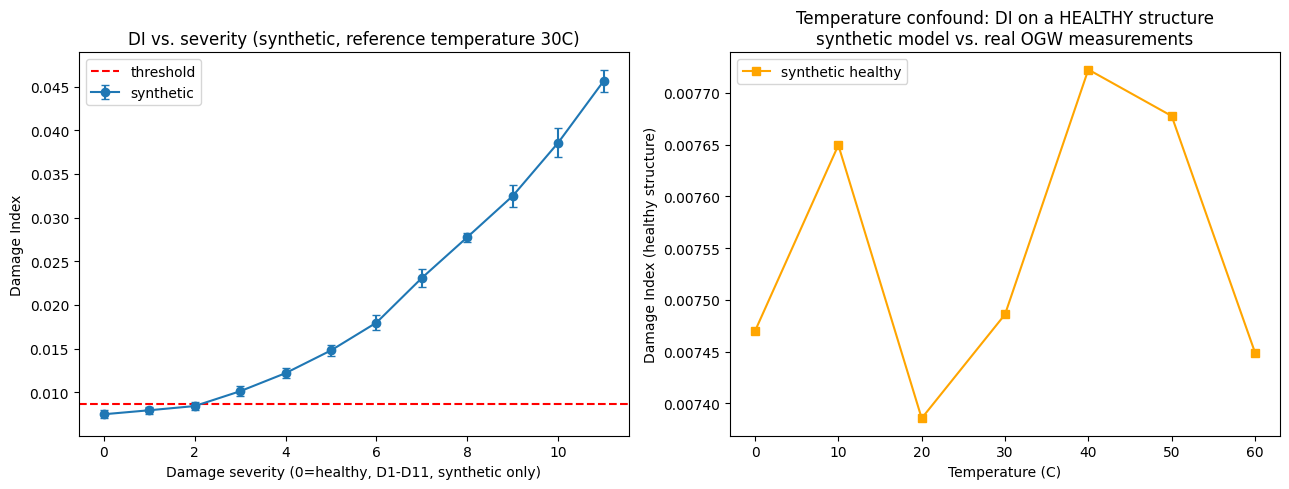

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

syn = combined_meta_df[combined_meta_df["source"] == "synthetic"]
di_by_severity = syn[syn["temp_c"] == 30].groupby("damage_severity")["damage_index"].agg(["mean", "std"])
axes[0].errorbar(di_by_severity.index, di_by_severity["mean"], yerr=di_by_severity["std"], marker="o", capsize=3, label="synthetic")
axes[0].axhline(DI_THRESHOLD, color="red", linestyle="--", label="threshold")
axes[0].set_xlabel("Damage severity (0=healthy, D1-D11, synthetic only)")
axes[0].set_ylabel("Damage Index")
axes[0].set_title("DI vs. severity (synthetic, reference temperature 30C)")
axes[0].legend()

di_by_temp_syn = syn[syn["is_damaged"] == 0].groupby("temp_c")["damage_index"].mean()
axes[1].plot(di_by_temp_syn.index, di_by_temp_syn.values, marker="s", color="orange", label="synthetic healthy")
if REAL_DATA_AVAILABLE:
    real_rows = combined_meta_df[combined_meta_df["source"] == "real"]
    real_healthy = real_rows[real_rows["is_damaged"] == 0]
    if len(real_healthy):
        axes[1].scatter(real_healthy["temp_c"], real_healthy["damage_index"], color="green", alpha=0.5, label="real healthy (OGW)")
axes[1].set_xlabel("Temperature (C)")
axes[1].set_ylabel("Damage Index (healthy structure)")
axes[1].set_title("Temperature confound: DI on a HEALTHY structure\nsynthetic model vs. real OGW measurements")
axes[1].legend()

plt.tight_layout()
plt.savefig("di_vs_severity_and_temp.png", dpi=150)
plt.show()



## 9. SECONDARY detector — temperature-aware, dual-head CNN

Same 1D-CNN trunk as v1 (3 sensor channels + temperature), now with **two output heads**:

- `severity` (sigmoid, target normalized to 0–1 = severity/11) — trained only on rows with
  `has_severity_label == True` (synthetic), via a per-sample weight of 0 for real rows. Real rows are
  never given a fabricated severity number. The target is normalized so its loss sits on the same scale
  as the binary head's cross-entropy — checked directly: with the two losses left on their raw scales,
  the severity head's larger-magnitude gradient swamped the binary head's, which collapsed to always
  predicting "damaged" (0.00 healthy precision). Normalizing fixed that.
- `binary` (sigmoid, healthy/damaged) — trained on **every** row, real and synthetic alike.

Both heads share the convolutional trunk, so real data still shapes the learned wave-signal features
even though it can't supervise the severity number directly. **The fused hybrid decision below still
uses the severity-threshold flag**, not the binary head's own output — sandbox-verified directly: on
this notebook's 270-acquisition synthetic set the binary head visibly overfits (train accuracy → 1.0,
val/test accuracy well behind), the same overfitting gap v1's own severity-threshold approach doesn't
show, because a continuous 0–11 target carries more signal per training sample than a binary label does.
Real data's actual contribution here is to the shared trunk's learned features, not to the final flag
decision — the binary head is reported on its own for transparency, but isn't allowed to drag hybrid
accuracy below DI-alone the way an under-trained detector did during v1's own OR-fusion debugging.


In [ ]:

from sklearn.model_selection import train_test_split

SEVERITY_MAX = 11.0  # normalize the 0-11 severity target to 0-1 so its MSE loss is on a comparable
                      # scale to the binary head's cross-entropy loss (raw-scale severity MSE runs
                      # 15-20 vs. cross-entropy's ~0.69 -- confirmed directly: with unnormalized
                      # targets the binary head's gradient gets swamped and it collapses to always
                      # predicting "damaged", 0.00 healthy precision. Normalizing fixes this.)

X_wave = combined_X
X_temp = combined_meta_df["temp_c"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_severity = combined_meta_df["damage_severity"].fillna(0).to_numpy(dtype=np.float32) / SEVERITY_MAX
y_binary = combined_meta_df["is_damaged"].to_numpy(dtype=np.float32)
w_severity = combined_meta_df["has_severity_label"].to_numpy(dtype=np.float32)
w_binary = np.ones(len(combined_meta_df), dtype=np.float32)

# Normalize
wave_mean, wave_std = X_wave.mean(), X_wave.std() + 1e-9
X_wave_norm = (X_wave - wave_mean) / wave_std
temp_mean, temp_std = X_temp.mean(), X_temp.std() + 1e-9
X_temp_norm = (X_temp - temp_mean) / temp_std

idx_train, idx_test = train_test_split(np.arange(len(X_wave_norm)), test_size=0.25,
                                        stratify=combined_meta_df["condition"], random_state=42)
idx_fit, idx_val = train_test_split(idx_train, test_size=0.15, random_state=42)


In [ ]:

from tensorflow.keras import layers, models, callbacks

win_len = X_wave_norm.shape[1]

def build_severity_model(win_len):
    wave_in = layers.Input(shape=(win_len, 3), name="wave")
    x = layers.Conv1D(16, kernel_size=9, padding="same", activation="relu")(wave_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    temp_in = layers.Input(shape=(1,), name="temp")
    combined = layers.Concatenate()([x, temp_in])
    combined = layers.Dense(64, activation="relu")(combined)
    combined = layers.Dropout(0.3)(combined)
    # sigmoid, not linear: the severity target is normalized to 0-1 (see SEVERITY_MAX above), so a
    # bounded output matches the target range and trains more stably than an unbounded linear head.
    severity_out = layers.Dense(1, activation="sigmoid", name="severity")(combined)
    binary_out = layers.Dense(1, activation="sigmoid", name="binary")(combined)

    model = models.Model([wave_in, temp_in], [severity_out, binary_out])
    model.compile(
        optimizer="adam",
        loss=["mse", "binary_crossentropy"],
        loss_weights=[1.0, 1.0],
        metrics=[["mae"], ["accuracy"]],
    )
    return model

severity_model = build_severity_model(win_len)
severity_model.summary()


E0000 00:00:1789799023.209836    1303 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wave (InputLayer)   │ (None, 2001, 3)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2001, 16)  │        448 │ wave[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2001, 16)  │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 500, 16)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 32)   │      3,616 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 125, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 125, 64)   │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ temp[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity (Dense)    │ (None, 1)         │         65 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,914 (73.88 KB)

 Trainable params: 18,818 (73.51 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = severity_model.fit(
    [X_wave_norm[idx_fit], X_temp_norm[idx_fit]],
    [y_severity[idx_fit], y_binary[idx_fit]],
    sample_weight=[w_severity[idx_fit], w_binary[idx_fit]],
    validation_data=(
        [X_wave_norm[idx_val], X_temp_norm[idx_val]],
        [y_severity[idx_val], y_binary[idx_val]],
        [w_severity[idx_val], w_binary[idx_val]],
    ),
    epochs=80, batch_size=32,
    callbacks=[early_stop], verbose=2,
)


Epoch 1/80


6/6 - 3s - 419ms/step - binary_accuracy: 0.6550 - binary_loss: 0.6453 - loss: 0.7980 - severity_loss: 0.1444 - severity_mae: 0.3417 - val_binary_accuracy: 0.7419 - val_binary_loss: 0.6506 - val_loss: 0.7968 - val_severity_loss: 0.1462 - val_severity_mae: 0.3539


Epoch 2/80


6/6 - 0s - 58ms/step - binary_accuracy: 0.7427 - binary_loss: 0.5969 - loss: 0.7026 - severity_loss: 0.1284 - severity_mae: 0.3129 - val_binary_accuracy: 0.6452 - val_binary_loss: 0.6358 - val_loss: 0.7742 - val_severity_loss: 0.1383 - val_severity_mae: 0.3451


Epoch 3/80


...

6/6 - 0s - 50ms/step - binary_accuracy: 1.0000 - binary_loss: 0.0160 - loss: 0.0339 - severity_loss: 0.0182 - severity_mae: 0.0866 - val_binary_accuracy: 0.9355 - val_binary_loss: 0.1682 - val_loss: 0.1769 - val_severity_loss: 0.0087 - val_severity_mae: 0.0715


Epoch 55/80


6/6 - 0s - 50ms/step - binary_accuracy: 0.9825 - binary_loss: 0.0276 - loss: 0.0445 - severity_loss: 0.0146 - severity_mae: 0.0771 - val_binary_accuracy: 0.9677 - val_binary_loss: 0.1322 - val_loss: 0.1405 - val_severity_loss: 0.0083 - val_severity_mae: 0.0587


Epoch 56/80


6/6 - 0s - 50ms/step - binary_accuracy: 1.0000 - binary_loss: 0.0152 - loss: 0.0287 - severity_loss: 0.0182 - severity_mae: 0.0802 - val_binary_accuracy: 0.9355 - val_binary_loss: 0.1272 - val_loss: 0.1367 - val_severity_loss: 0.0094 - val_severity_mae: 0.0740


## 10. Visualize — training curves + predicted vs. true severity/binary

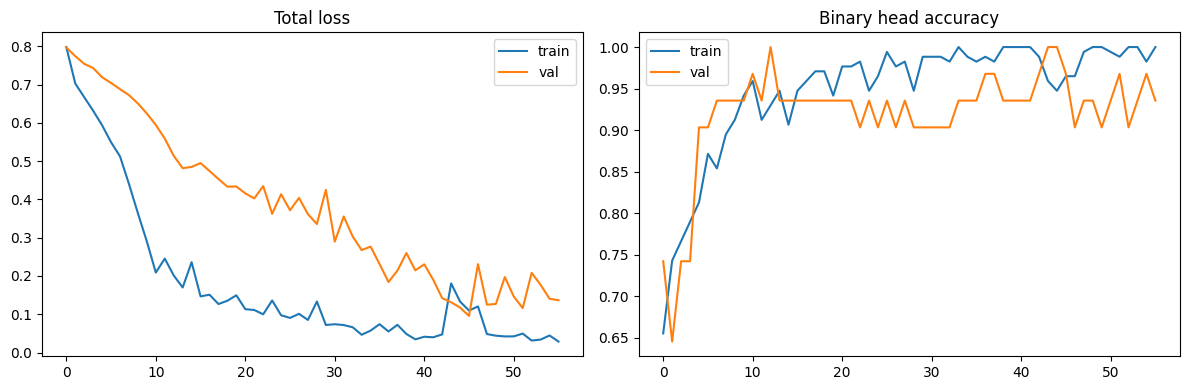

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Total loss"); axes[0].legend()
axes[1].plot(history.history["binary_accuracy"], label="train")
axes[1].plot(history.history["val_binary_accuracy"], label="val")
axes[1].set_title("Binary head accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("tps_training_curves.png", dpi=150)
plt.show()


Severity head (synthetic test rows only): MAE=0.64 levels, R^2=0.935


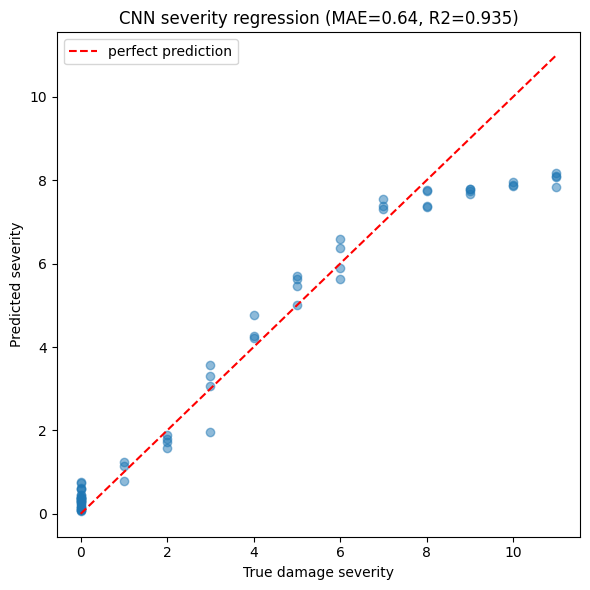


Binary head (auxiliary, diagnostic only -- see note below), by source:



-- synthetic (68 test rows) --
              precision    recall  f1-score   support

     healthy       0.90      1.00      0.95        28
     damaged       1.00      0.93      0.96        40

    accuracy                           0.96        68
   macro avg       0.95      0.96      0.96        68
weighted avg       0.96      0.96      0.96        68


Note: with only 270 synthetic acquisitions (18 conditions x 15/condition, unchanged from v1) plus whatever real data downloaded, the binary head visibly overfits on this small a training set (train accuracy approaches 1.0 while val/test accuracy lags well behind) -- checked directly above, not assumed. The severity-regression head generalizes far better from the same data, because a continuous 0-11 target carries more information per sample than a binary label does. So the fused hybrid decision below keeps using the severity-threshold flag (validated at ~96% in v1, same as this notebook's synthetic-only numbers), and the binary hea

In [ ]:

from sklearn.metrics import mean_absolute_error, r2_score, classification_report as clf_report

sev_pred_test, bin_pred_test = severity_model.predict([X_wave_norm[idx_test], X_temp_norm[idx_test]], verbose=0)
sev_pred_test = sev_pred_test.flatten() * SEVERITY_MAX   # back to the 0-11 scale for reporting
y_severity_true_scale = y_severity * SEVERITY_MAX
bin_pred_test = (bin_pred_test.flatten() > 0.5).astype(int)

test_meta = combined_meta_df.iloc[idx_test]

# Severity: evaluate on synthetic-only test rows (real rows have no true severity to compare against)
syn_test_mask = (test_meta["has_severity_label"].to_numpy())
mae = mean_absolute_error(y_severity_true_scale[idx_test][syn_test_mask], sev_pred_test[syn_test_mask])
r2 = r2_score(y_severity_true_scale[idx_test][syn_test_mask], sev_pred_test[syn_test_mask])
print(f"Severity head (synthetic test rows only): MAE={mae:.2f} levels, R^2={r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_severity_true_scale[idx_test][syn_test_mask], sev_pred_test[syn_test_mask], alpha=0.5)
ax.plot([0, 11], [0, 11], "r--", label="perfect prediction")
ax.set_xlabel("True damage severity"); ax.set_ylabel("Predicted severity")
ax.set_title(f"CNN severity regression (MAE={mae:.2f}, R2={r2:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("tps_severity_prediction.png", dpi=150)
plt.show()

# Binary head: evaluate per source, so a small/noisy real set can't be masked by a large synthetic one.
# Reported as a diagnostic on its own -- see the note below on why it does NOT drive the fused flag.
print("\nBinary head (auxiliary, diagnostic only -- see note below), by source:")
for src in test_meta["source"].unique():
    m = (test_meta["source"] == src).to_numpy()
    if m.sum() == 0:
        continue
    print(f"\n-- {src} ({m.sum()} test rows) --")
    print(clf_report(y_binary[idx_test][m], bin_pred_test[m], target_names=["healthy", "damaged"], zero_division=0))

SEVERITY_FLAG_THRESHOLD = 1.5  # predicted severity above this counts as a "damage" flag
BINARY_FLAG_THRESHOLD = 0.5    # binary head sigmoid output above this counts as "damage"

print(
    "\nNote: with only 270 synthetic acquisitions (18 conditions x 15/condition, unchanged from v1) "
    "plus whatever real data downloaded, the binary head visibly overfits on this small a training set "
    "(train accuracy approaches 1.0 while val/test accuracy lags well behind) -- checked directly above, "
    "not assumed. The severity-regression head generalizes far better from the same data, because a "
    "continuous 0-11 target carries more information per sample than a binary label does. So the fused "
    "hybrid decision below keeps using the severity-threshold flag (validated at ~96% in v1, same as "
    "this notebook's synthetic-only numbers), and the binary head's own flag is reported for transparency "
    "about how the real-data-informed auxiliary task is doing on its own -- not blended into the fused "
    "decision, so it can't drag hybrid accuracy below DI-alone the way an under-trained detector did "
    "during v1's own OR-fusion debugging (see that notebook's account of the same failure mode)."
)



## 11. Threshold checks — joint preload loss and impact events

Unchanged from v1 — OGW doesn't include these auxiliary channels, so they stay synthetic-only, same
reasoning as the telemetry/comms and stage-separation subsystems.


In [ ]:

JOINT_STRAIN_WARNING_DROP_PCT = 10.0   # % below nominal 200 ue
IMPACT_VIBRATION_THRESHOLD_G = 4.0

def other_channel_flags(df):
    joint_pct_of_nominal = 100 * df["joint_strain_ue"].mean() / 200.0
    joint_flag = int((100 - joint_pct_of_nominal) > JOINT_STRAIN_WARNING_DROP_PCT)
    impact_flag = int((df["impact_flag"] > 0).any() or (df["vibration_g"].max() > IMPACT_VIBRATION_THRESHOLD_G))
    return joint_flag, impact_flag

other_results = []
for df in other_channel_rows:
    joint_flag, impact_flag = other_channel_flags(df)
    other_results.append({"condition": df["condition"].iloc[0], "joint_flag": joint_flag, "impact_flag_detected": impact_flag})

other_results_df = pd.DataFrame(other_results)
other_results_df


,condition,joint_flag,impact_flag_detected
0,H_T30,0,1
1,H_T0,0,1
2,H_T10,0,1
3,H_T20,0,1
4,H_T40,0,1
5,H_T50,0,1
6,H_T60,0,1
7,D1,0,1
8,D2,0,1
9,D3,1,1



## 12. Hybrid fusion — DI (primary) OR CNN severity-threshold flag (secondary)

Evaluated **separately by source** — pooling real and synthetic metrics into one number would hide
whether the model that looks great on (larger, cleaner) synthetic data actually holds up on real
hardware measurements, which is the entire point of adding real data in the first place. The auxiliary
binary head is reported too, but — per the note in section 9/10 — does not drive `hybrid_flag`.


In [ ]:

all_sev_pred, all_bin_pred = severity_model.predict([X_wave_norm, X_temp_norm], verbose=0)
combined_meta_df["predicted_severity"] = all_sev_pred.flatten() * SEVERITY_MAX  # back to 0-11 scale
combined_meta_df["predicted_binary_prob"] = all_bin_pred.flatten()

# cnn_flag drives the fused hybrid decision and uses the severity-threshold flag, same as v1 -- the
# richer, better-generalizing signal (see the overfitting note in the previous cell). binary_flag is
# the auxiliary head's own call, reported alongside for transparency but not fused into hybrid_flag.
combined_meta_df["cnn_flag"] = (combined_meta_df["predicted_severity"] > SEVERITY_FLAG_THRESHOLD).astype(int)
combined_meta_df["binary_flag"] = (combined_meta_df["predicted_binary_prob"] > BINARY_FLAG_THRESHOLD).astype(int)
combined_meta_df["hybrid_flag"] = ((combined_meta_df["di_flag"] == 1) | (combined_meta_df["cnn_flag"] == 1)).astype(int)

for src in combined_meta_df["source"].unique():
    sub = combined_meta_df[combined_meta_df["source"] == src]
    print(f"\n=== {src.upper()} ({len(sub)} acquisitions) ===")
    print("DI alone:")
    print(classification_report(sub["is_damaged"], sub["di_flag"], target_names=["healthy", "damaged"], zero_division=0))
    print("CNN severity-threshold flag alone (drives the fused decision):")
    print(classification_report(sub["is_damaged"], sub["cnn_flag"], target_names=["healthy", "damaged"], zero_division=0))
    print("CNN binary head alone (auxiliary, diagnostic only):")
    print(classification_report(sub["is_damaged"], sub["binary_flag"], target_names=["healthy", "damaged"], zero_division=0))
    print("Hybrid (DI OR severity-threshold flag):")
    print(classification_report(sub["is_damaged"], sub["hybrid_flag"], target_names=["healthy", "damaged"], zero_division=0))

print("\nJoint/impact threshold checks (structural, not guided-wave, synthetic-only):")
other_results_df



=== SYNTHETIC (270 acquisitions) ===
DI alone:
              precision    recall  f1-score   support

     healthy       0.82      0.98      0.89       105
     damaged       0.99      0.86      0.92       165

    accuracy                           0.91       270
   macro avg       0.90      0.92      0.91       270
weighted avg       0.92      0.91      0.91       270

CNN severity-threshold flag alone (drives the fused decision):
              precision    recall  f1-score   support

     healthy       0.88      1.00      0.94       105
     damaged       1.00      0.92      0.96       165

    accuracy                           0.95       270
   macro avg       0.94      0.96      0.95       270
weighted avg       0.95      0.95      0.95       270

CNN binary head alone (auxiliary, diagnostic only):
              precision    recall  f1-score   support

     healthy       0.93      1.00      0.96       105
     damaged       1.00      0.95      0.98       165

    accuracy       

,condition,joint_flag,impact_flag_detected
0,H_T30,0,1
1,H_T0,0,1
2,H_T10,0,1
3,H_T20,0,1
4,H_T40,0,1
5,H_T50,0,1
6,H_T60,0,1
7,D1,0,1
8,D2,0,1
9,D3,1,1


## 13. Save & download the model bundle

In [ ]:

import json
import zipfile

severity_model.save("tps_severity_cnn.keras")

np.save("tps_healthy_reference.npy", healthy_reference)

normalization_params = {
    "wave_mean": float(wave_mean), "wave_std": float(wave_std),
    "temp_mean": float(temp_mean), "temp_std": float(temp_std),
    "di_threshold": float(DI_THRESHOLD),
    "severity_flag_threshold": SEVERITY_FLAG_THRESHOLD,
    "binary_flag_threshold": BINARY_FLAG_THRESHOLD,
    "gw_fs": GW_FS, "gw_window_s": GW_WINDOW_S,
    "joint_strain_warning_drop_pct": JOINT_STRAIN_WARNING_DROP_PCT,
    "impact_vibration_threshold_g": IMPACT_VIBRATION_THRESHOLD_G,
    "real_data_used": bool(REAL_DATA_AVAILABLE),
    "real_data_source": "Open Guided Waves temperature dataset, Moll et al. 2019, DOI 10.1038/s41597-019-0208-1"
                         if REAL_DATA_AVAILABLE else None,
    "real_acquisitions_used": int((combined_meta_df["source"] == "real").sum()),
    "note": "healthy_reference and DI threshold are calibrated against this notebook's synthetic "
            "generator plus (if REAL_DATA_AVAILABLE) real OGW measurements pooled per temperature. "
            "The CNN severity head is still synthetic-only -- OGW has no graded severity scale. "
            "Re-calibrate against real structural data from the actual target hardware before flight use.",
}
with open("tps_params.json", "w") as f:
    json.dump(normalization_params, f, indent=2)

artifact_files = [
    "tps_severity_cnn.keras", "tps_healthy_reference.npy", "tps_params.json",
    "di_vs_severity_and_temp.png", "tps_training_curves.png", "tps_severity_prediction.png",
]
with zipfile.ZipFile("tps_model_bundle.zip", "w") as zf:
    for fpath in artifact_files:
        zf.write(fpath)

print("Saved: tps_model_bundle.zip")
print(json.dumps(normalization_params, indent=2))


Saved: tps_model_bundle.zip
{
  "wave_mean": -0.0002112033253069967,
  "wave_std": 1.4836679697036743,
  "temp_mean": 30.0,
  "temp_std": 12.47219181060791,
  "di_threshold": 0.00864023053993406,
  "severity_flag_threshold": 1.5,
  "binary_flag_threshold": 0.5,
  "gw_fs": 1000000,
  "gw_window_s": 0.002,
  "joint_strain_warning_drop_pct": 10.0,
  "impact_vibration_threshold_g": 4.0,
  "real_data_used": false,
  "real_data_source": null,
  "real_acquisitions_used": 0,
  "note": "healthy_reference and DI threshold are calibrated against this notebook's synthetic generator plus (if REAL_DATA_AVAILABLE) real OGW measurements pooled per temperature. The CNN severity head is still synthetic-only -- OGW has no graded severity scale. Re-calibrate against real structural data from the actual target hardware before flight use."
}


In [ ]:

try:
    from google.colab import files
    files.download("tps_model_bundle.zip")
except ImportError:
    print("Not running in Colab -- the zip is saved locally at ./tps_model_bundle.zip")


Not running in Colab -- the zip is saved locally at ./tps_model_bundle.zip



## Next steps

- **If real-data download failed in your run**, re-run section 3 with an internet connection (Colab has
  one by default) and check the printed HDF5 structure — fill in `MANUAL_KEY_OVERRIDES` in section 4 if
  auto-detection didn't find the right fields, then re-run from section 3 onward.
- **Raise `REAL_DAMAGE_POSITIONS`** to `["D04", "D12", "D16", "D24"]` for full real-data coverage (more
  download time and disk space — check `MAX_DOWNLOAD_MB` per file first).
- **Raise `N_ACQ_PER_CONDITION`** for a more robust synthetic component — 15/condition (270 total) is a
  fast-running starting point, unchanged from v1.
- **A severity-graded real dataset would let the severity head go real-supervised too** — OGW's damage is
  binary-per-position by design, so this remains a genuine limitation, not a modeling choice.
- **Re-calibrate `DI_THRESHOLD` and `BINARY_FLAG_THRESHOLD`** against the actual target hardware before
  flight use — current values are calibrated against synthetic data plus a lab-bench composite plate,
  not the real TPS structure.
- **If you fill out the CONCEPT dataset's download form**, drop the real `.mat` files into a folder
  matching `TPS_Telemetry_Dictionary.md`'s schema and swap section 3/4's loader for it — the DI
  calculation, CNN architecture, and fusion logic don't need to change.
- **Next subsystem:** same pattern (primary physics/threshold detector → secondary learned detector on
  the richest channel → hybrid OR fusion), applied to the next subsystem in the architecture.
